# Cyclone Partitions Compact PTM4

This workflow keeps cyclone methodology but reduces file count:
- one file per **grid+cyclone** containing all variables
- optional one file per **cyclone merged across all grids**

No BMUs or JSON statistics are generated.


## Pipeline
1. Read reconstructed spectra per grid and cyclone id.
2. Filter sites to isobath 500 m points (KDTree tolerance).
3. Compute full-spectrum bulk vars + PTM4 partitions.
4. Save one compact NetCDF per grid+cyclone with all variables.
5. Optionally smooth-merge grids and save one NetCDF per cyclone.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from paths import GEBCO_FILE, ISOBATH_GEOJSON, predicted_emu_tracks

GRID_NAMES = ['grid1', 'grid2', 'grid3', 'grid4']

WIND_DATA_PATH = predicted_emu_tracks('ssp585')
ISOBATH_POINTS_FILE = ISOBATH_GEOJSON



COMPACT_DIR = PROJECT_ROOT / 'outputs' / 'partitions_cyclones_compact_ptm4_v1'
MERGED_DIR = PROJECT_ROOT / 'outputs' / 'merged_cyclones_compact_ptm4_v1'

# Cyclone controls
CYCLONE_START_ID = 0
CYCLONE_END_ID = 1900
MAX_CYCLONES_PER_GRID = None

# For quick tests, use a list like [0,1,2]; keep None for all common IDs
MERGE_ONLY_CYCLONE_IDS = None

SKIP_EXISTING = True
POINT_MATCH_TOL = 1e-6
MERGE_N_JOBS = 4  # process workers; 1 is fine (~15 min for 1828)

SMOOTH_STEEPNESS = 2.0
BLEND_BUFFER_KM = 30.0
TOLERANCE_DEG = 0.001

if str(PROJECT_ROOT) not in sys.path:

from utils import partitions_cyclones_ptm4_compact as pc

COMPACT_DIR.mkdir(parents=True, exist_ok=True)
MERGED_DIR.mkdir(parents=True, exist_ok=True)

print('Project:', PROJECT_ROOT)
print('Compact output:', COMPACT_DIR)
print('Merged output:', MERGED_DIR)


Project: .
Compact output: ./outputs/partitions_cyclones_compact_ptm4_v1
Merged output: ./outputs/merged_cyclones_compact_ptm4_v1


## 1) Build compact PTM4 partitions (one file per grid+cyclone)


In [2]:
compact_files = pc.build_compact_ptm4_partitions(
    project_root=PROJECT_ROOT,
    output_dir=COMPACT_DIR,
    grid_names=GRID_NAMES,
    wind_data_path=WIND_DATA_PATH,
    gebco_file=GEBCO_FILE,
    isobath_geojson=ISOBATH_POINTS_FILE,
    cyclone_start_id=CYCLONE_START_ID,
    cyclone_end_id=CYCLONE_END_ID,
    max_cyclones_per_grid=MAX_CYCLONES_PER_GRID,
    point_match_tolerance=POINT_MATCH_TOL,
    skip_existing=SKIP_EXISTING,
)

print(f'Generated/available compact files: {len(compact_files)}')
for p in sorted(compact_files)[:10]:
    print('  ', p.name)


Isobath points loaded: 2244
[grid1] Processing 1785 cyclone files


grid1: PTM4 compact:   0%|          | 0/1785 [00:00<?, ?it/s]

[grid1] keeping 401/908 sites
[grid2] Processing 1785 cyclone files


grid2: PTM4 compact:   0%|          | 0/1785 [00:00<?, ?it/s]

[grid2] keeping 470/1120 sites
[grid3] Processing 1785 cyclone files


grid3: PTM4 compact:   0%|          | 0/1785 [00:00<?, ?it/s]

[grid3] keeping 648/1627 sites
[grid4] Processing 1785 cyclone files


grid4: PTM4 compact:   0%|          | 0/1785 [00:00<?, ?it/s]

[grid4] keeping 310/959 sites
Generated/available compact files: 7140
   cyclone_0_grid1_allvars_ptm4.nc
   cyclone_0_grid2_allvars_ptm4.nc
   cyclone_0_grid3_allvars_ptm4.nc
   cyclone_0_grid4_allvars_ptm4.nc
   cyclone_1000_grid1_allvars_ptm4.nc
   cyclone_1000_grid2_allvars_ptm4.nc
   cyclone_1000_grid3_allvars_ptm4.nc
   cyclone_1000_grid4_allvars_ptm4.nc
   cyclone_1001_grid1_allvars_ptm4.nc
   cyclone_1001_grid2_allvars_ptm4.nc


## 2) Discover common cyclone IDs


In [3]:
common_ids = pc.discover_compact_cyclone_ids(COMPACT_DIR, GRID_NAMES, intersection=True)
print('Common cyclone IDs across all grids:', len(common_ids))
if common_ids:
    print('min/max:', common_ids[0], common_ids[-1])


Common cyclone IDs across all grids: 1785
min/max: 0 1784


## 3) Merge all grids per cyclone (one file per cyclone)


In [4]:
merged_files = pc.merge_compact_cyclones_smooth(
    compact_dir=COMPACT_DIR,
    output_dir=MERGED_DIR,
    grid_names=GRID_NAMES,
    cyclone_ids=MERGE_ONLY_CYCLONE_IDS,
    steepness=SMOOTH_STEEPNESS,
    blend_buffer_km=BLEND_BUFFER_KM,
    tolerance_deg=TOLERANCE_DEG,
    skip_existing=SKIP_EXISTING,
    n_jobs=MERGE_N_JOBS,
)

print(f'Merged cyclone files: {len(merged_files)}')
for p in sorted(merged_files)[:10]:
    print('  ', p.name, f'({p.stat().st_size/1e6:.1f} MB)')


Building merge plan from cyclone 0 (4 grids)...


Build merge plan:   0%|          | 0/1356 [00:00<?, ?it/s]

Merge plan ready: 1356 sites
Merging 1785 cyclones (0 already done), n_jobs=4


Merging cyclones:   0%|          | 0/1785 [00:00<?, ?it/s]

Merged cyclone files: 1785
   cyclone_0_merged_allvars_ptm4.nc (0.7 MB)
   cyclone_1000_merged_allvars_ptm4.nc (0.6 MB)
   cyclone_1001_merged_allvars_ptm4.nc (1.1 MB)
   cyclone_1002_merged_allvars_ptm4.nc (1.1 MB)
   cyclone_1003_merged_allvars_ptm4.nc (0.7 MB)
   cyclone_1004_merged_allvars_ptm4.nc (0.4 MB)
   cyclone_1005_merged_allvars_ptm4.nc (0.7 MB)
   cyclone_1006_merged_allvars_ptm4.nc (0.4 MB)
   cyclone_1007_merged_allvars_ptm4.nc (0.9 MB)
   cyclone_1008_merged_allvars_ptm4.nc (0.8 MB)


## 4) Quick check of one merged cyclone file


In [6]:
import xarray as xr

if merged_files:
    sample = sorted(merged_files)[0]
    with xr.open_dataset(sample) as ds:
        print('Sample:', sample.name)
        print('Dims:', dict(ds.sizes))
        print('Vars:', list(ds.data_vars))
        print('cyclone_id:', ds.coords['cyclone_id'].values)
else:
    print('No merged files yet.')


Sample: cyclone_0_merged_allvars_ptm4.nc
Dims: {'time': 24, 'site': 1356}
Vars: ['hs', 'tp', 'tm02', 'dp', 'dm', 'phs0', 'ptp0', 'pdp0', 'spr0', 'phs1', 'ptp1', 'pdp1', 'spr1']
cyclone_id: 0


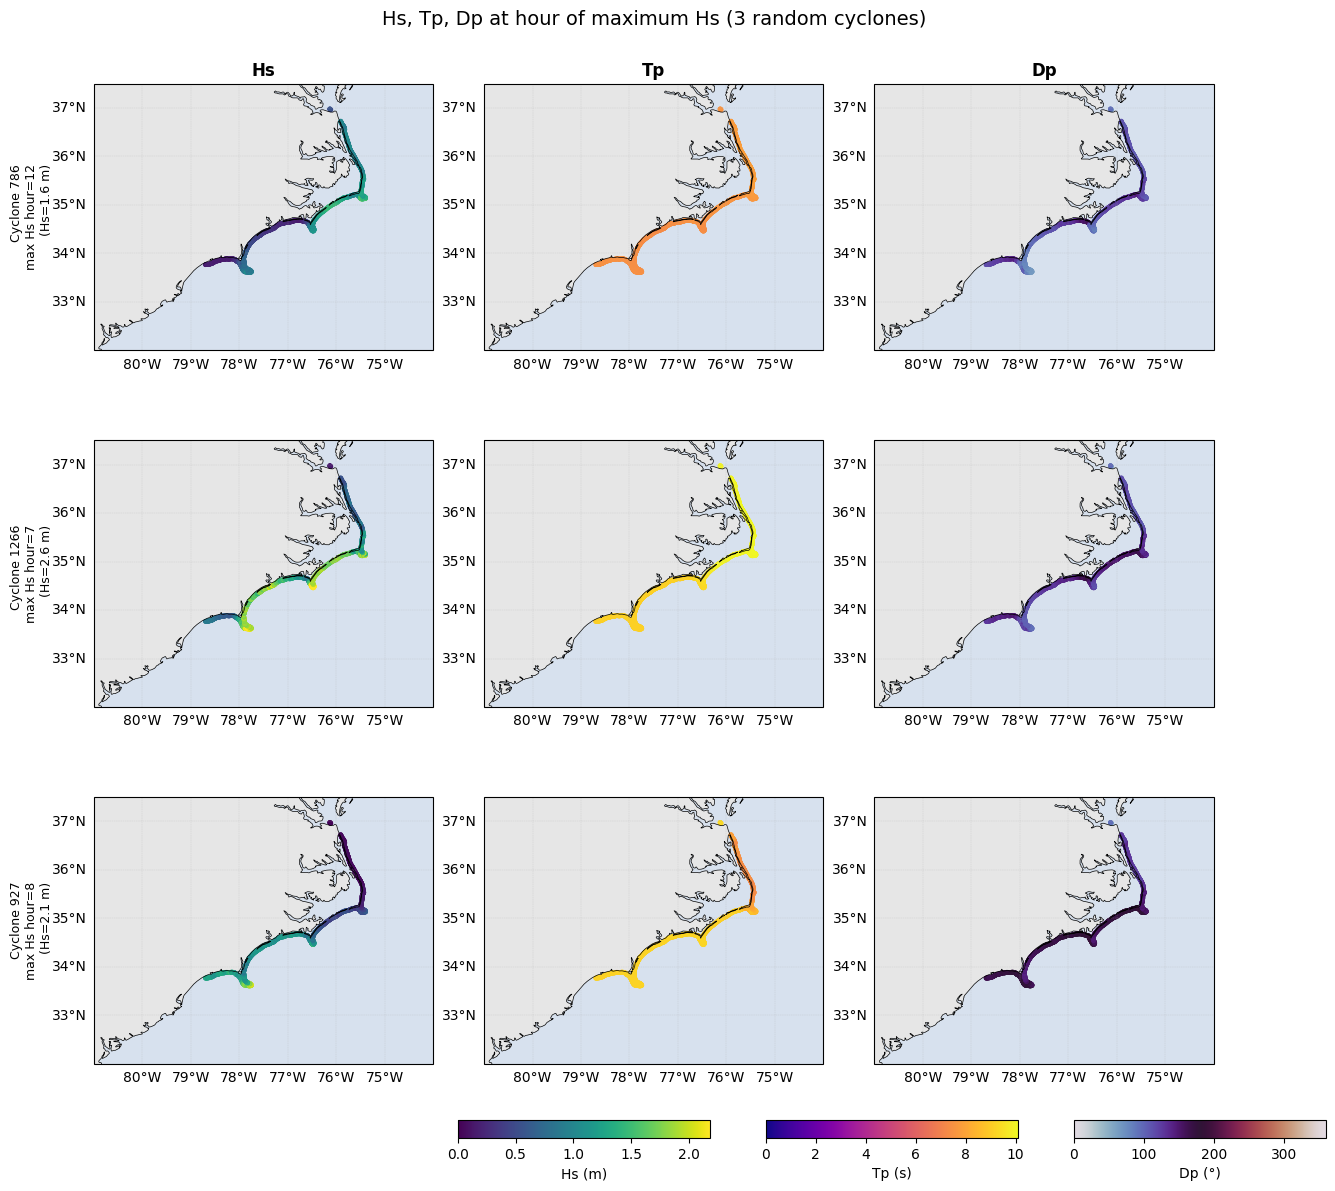

Cyclone 786: max Hs hour = 12, Hs_max = 1.63 m
Cyclone 1266: max Hs hour = 7, Hs_max = 2.63 m
Cyclone 927: max Hs hour = 8, Hs_max = 2.08 m


In [7]:
import random
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

MERGED_DIR = Path(
    "./outputs/merged_cyclones_compact_ptm4_v1"
)
COMPACT_DIR = Path(
    "./outputs/partitions_cyclones_compact_ptm4_v1"
)
GRIDS = ["grid1", "grid2", "grid3", "grid4"]
EXTENT = [-81.0, -74.0, 32.0, 37.5]
RANDOM_SEED = 123
N_CYCLONES = 3

VARS = [
    ("hs", "Hs (m)", "viridis"),
    ("tp", "Tp (s)", "plasma"),
    ("dp", "Dp (°)", "twilight"),
]


def load_cyclone(cid: int) -> xr.Dataset:
    """Load merged cyclone file; fall back to concatenated compact grids if empty."""
    merged_path = MERGED_DIR / f"cyclone_{cid}_merged_allvars_ptm4.nc"
    if merged_path.is_file():
        ds = xr.open_dataset(merged_path)
        if np.isfinite(ds["hs"].values).any():
            return ds

    parts = [
        xr.open_dataset(COMPACT_DIR / f"cyclone_{cid}_{grid}_allvars_ptm4.nc")
        for grid in GRIDS
        if (COMPACT_DIR / f"cyclone_{cid}_{grid}_allvars_ptm4.nc").is_file()
    ]
    if not parts:
        raise FileNotFoundError(f"No data found for cyclone {cid}")
    return xr.concat(parts, dim="site")


def hour_of_max_hs(ds: xr.Dataset) -> int:
    """Time index where domain-wide maximum Hs occurs."""
    hs = ds["hs"].values  # (time, site)
    return int(np.nanargmax(np.nanmax(hs, axis=1)))


def pick_random_cyclones(n: int = N_CYCLONES, seed: int = RANDOM_SEED) -> list[int]:
    rng = random.Random(seed)
    ids = sorted(
        int(p.stem.split("_")[1])
        for p in MERGED_DIR.glob("cyclone_*_merged_allvars_ptm4.nc")
    )
    rng.shuffle(ids)
    selected = []
    for cid in ids:
        with load_cyclone(cid) as ds:
            hs_max = float(np.nanmax(ds["hs"].values))
        if np.isfinite(hs_max) and hs_max > 0.5:
            selected.append(cid)
        if len(selected) >= n:
            break
    if len(selected) < n:
        raise RuntimeError(f"Only found {len(selected)} cyclones with valid data")
    return selected


def setup_map(ax):
    ax.set_extent(EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="0.9", linewidth=0)
    ax.add_feature(cfeature.OCEAN, facecolor="lightsteelblue", alpha=0.5, linewidth=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="k")
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False


cyclone_ids = pick_random_cyclones()
datasets = [load_cyclone(cid) for cid in cyclone_ids]
peak_hours = [hour_of_max_hs(ds) for ds in datasets]
peak_hs = [
    float(np.nanmax(ds["hs"].isel(time=h).values))
    for ds, h in zip(datasets, peak_hours)
]

hs_vals = [ds["hs"].isel(time=h).values for ds, h in zip(datasets, peak_hours)]
tp_vals = [ds["tp"].isel(time=h).values for ds, h in zip(datasets, peak_hours)]
hs_vmax = max(float(np.nanpercentile(np.concatenate(hs_vals), 99)), 0.01)
tp_vmax = max(float(np.nanpercentile(np.concatenate(tp_vals), 99)), 0.1)

fig, axes = plt.subplots(
    N_CYCLONES,
    3,
    figsize=(14, 12),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

scatters = {var: [] for var, _, _ in VARS}
for row, (cid, ds, h, hs_m) in enumerate(
    zip(cyclone_ids, datasets, peak_hours, peak_hs)
):
    lon = ds["lon"].values
    lat = ds["lat"].values
    for col, (var, label, cmap) in enumerate(VARS):
        ax = axes[row, col]
        setup_map(ax)
        vals = ds[var].isel(time=h).values
        if var == "hs":
            vmin, vmax = 0.0, hs_vmax
        elif var == "tp":
            vmin, vmax = 0.0, tp_vmax
        else:
            vmin, vmax = 0.0, 360.0
        sc = ax.scatter(
            lon,
            lat,
            c=vals,
            s=6,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            transform=ccrs.PlateCarree(),
        )
        scatters[var].append(sc)
        if row == 0:
            ax.set_title(label.split()[0], fontsize=12, fontweight="bold")
        if col == 0:
            ax.text(
                -0.12,
                0.5,
                f"Cyclone {cid}\nmax Hs hour={h}\n(Hs={hs_m:.1f} m)",
                transform=ax.transAxes,
                va="center",
                ha="right",
                fontsize=9,
                rotation=90,
            )

for i, (var, label, _) in enumerate(VARS):
    cax = fig.add_axes([0.36 + i * 0.22, 0.04, 0.18, 0.015])
    cb = fig.colorbar(scatters[var][0], cax=cax, orientation="horizontal")
    cb.set_label(label)

fig.suptitle("Hs, Tp, Dp at hour of maximum Hs (3 random cyclones)", y=0.98, fontsize=14)
plt.subplots_adjust(left=0.10, bottom=0.08, top=0.94, wspace=0.15, hspace=0.12)
plt.show()

for ds in datasets:
    ds.close()

for cid, h, hs_m in zip(cyclone_ids, peak_hours, peak_hs):
    print(f"Cyclone {cid}: max Hs hour = {h}, Hs_max = {hs_m:.2f} m")
